ARIMA Modeling for Apple Stock Prediction

To build an ARIMA model to predict future stock returns for Apple and evaluate its performance in capturing market dynamics.

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

Data Loading and Preparation

In this step, we load the historical stock data and prepare it for time-series modeling by converting the Date column and setting it as the index.

In [2]:
import pandas as pd

df = pd.read_csv("../../data/Apple.csv")

df.columns = df.columns.str.strip()   # clean column names

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.columns)  # check columns

# Use correct column
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split

The dataset is split based on time to prevent data leakage.

- Training Data: 2015–2023
- Testing Data: 2024 onwards

This ensures that the model is evaluated on future unseen data.

In [3]:
train = df[df.index < "2024-01-01"]['Return']
test = df[df.index >= "2024-01-01"]['Return']

ARIMA Parameter Tuning

We perform a grid search over different ARIMA parameters (p, d, q) and select the best combination based on the lowest AIC value.

This step ensures that the model is optimized rather than using arbitrary parameters.

In [4]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

orders = [(1,1,1), (2,1,2), (3,1,1)]

for order in orders:
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=len(test))
    
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"Order {order} → RMSE: {rmse}")

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2264
Model:                 ARIMA(2, 1, 2)   Log Likelihood                5844.133
Date:                Fri, 10 Apr 2026   AIC                         -11678.266
Time:                        22:02:41   BIC                         -11649.644
Sample:                             0   HQIC                        -11667.822
                               - 2264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9937      0.033    -30.509      0.000      -1.057      -0.930
ar.L2         -0.0966      0.014     -6.876      0.000      -0.124      -0.069
ma.L1         -0.0750      0.032     -2.312      0.0

Train Final ARIMA Model

Model Training

Using the optimal parameters, the ARIMA model is trained on the training dataset to learn patterns in stock returns.

In [5]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

Model Predictions

The trained ARIMA model is used to forecast future returns over the test period.

In [6]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(2,1,2))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test.iloc[t])

Model Evaluation

The model is evaluated using the following metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Directional Accuracy

These metrics help assess prediction accuracy and the model's ability to capture market direction.

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.011687892193248799
RMSE: 0.017600592202765535


Actual vs Predicted Comparison

This visualization compares the predicted returns with actual returns.

It helps evaluate whether the model captures trends, fluctuations, and market dynamics effectively.

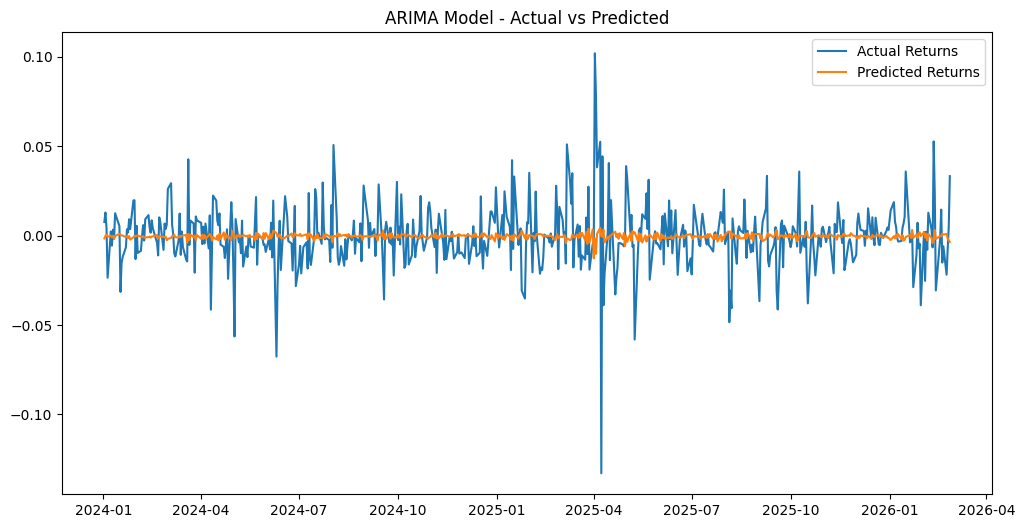

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual Returns")
plt.plot(test.index, predictions, label="Predicted Returns")

plt.title("ARIMA Model - Actual vs Predicted")
plt.legend()
plt.show()

Converting predictions to buy or sell decisions

Get Predicted Returns

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/Amazon.csv")

df.columns = df.columns.str.strip()

print(df.columns)  # now you should see 'Close' correctly

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Use Close or Adj Close (both now work)
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split

In [10]:
train = df[df.index < "2024-01-01"]
test = df[df.index >= "2024-01-01"]

ARIMA Predictions

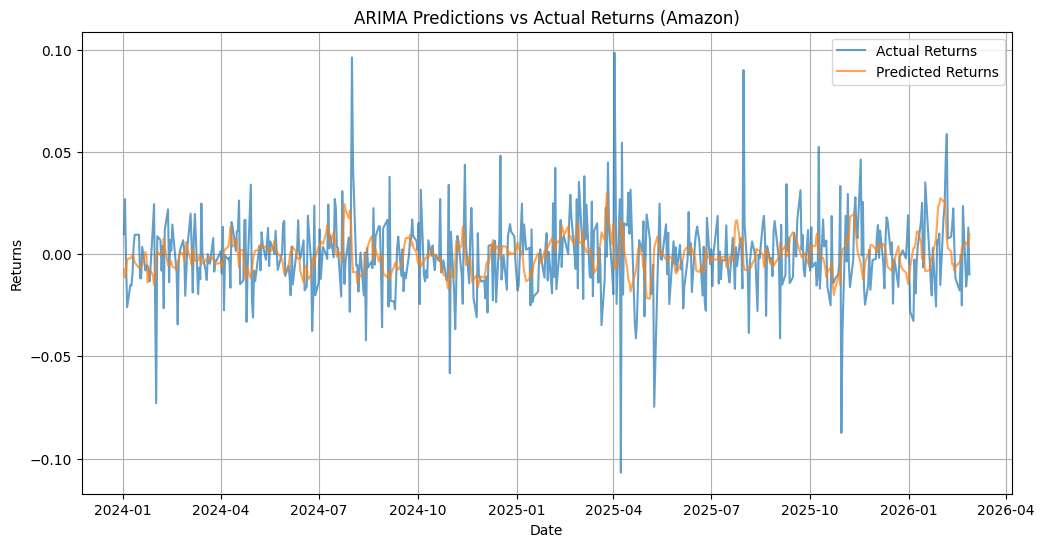

In [11]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train['Return'])
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))  # you can adjust order
    model_fit = model.fit()
    
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    history.append(test['Return'].iloc[t])

test['Predicted_Return'] = predictions


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Return'], label='Actual Returns', alpha=0.7)
plt.plot(test.index, test['Predicted_Return'], label='Predicted Returns', alpha=0.7)

plt.title("ARIMA Predictions vs Actual Returns (Amazon)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid()

plt.show()

Convert Predictions → Trading Signals

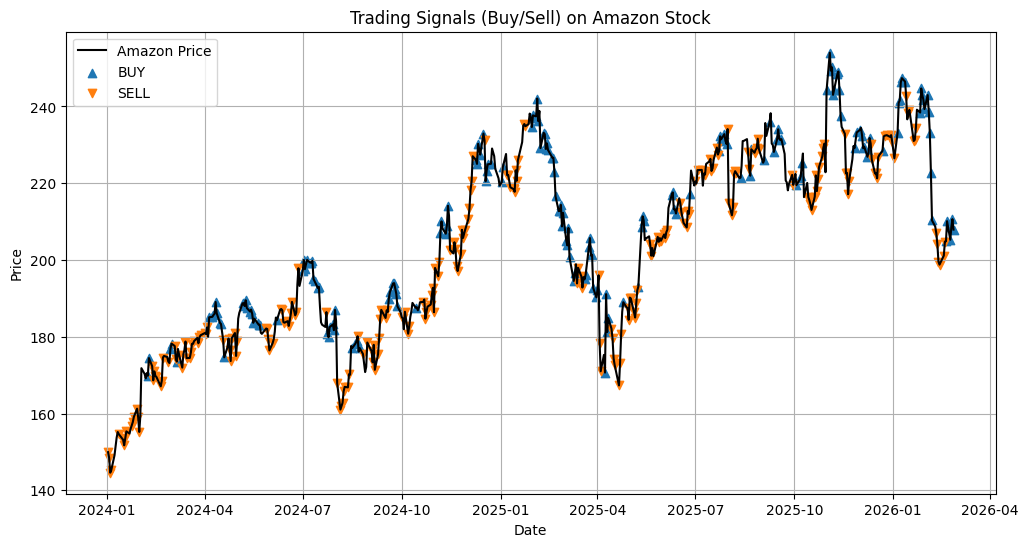

In [12]:
def get_signal(x):
    if x > 0.002:
        return "BUY"
    elif x < -0.002:
        return "SELL"
    else:
        return "HOLD"

test['Signal'] = test['Predicted_Return'].apply(get_signal)


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Close'], label='Amazon Price', color='black')

buy_signals = test[test['Signal'] == 'BUY']
sell_signals = test[test['Signal'] == 'SELL']

plt.scatter(buy_signals.index, buy_signals['Close'], label='BUY', marker='^')
plt.scatter(sell_signals.index, sell_signals['Close'], label='SELL', marker='v')

plt.title("Trading Signals (Buy/Sell) on Amazon Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

Strategy Returns

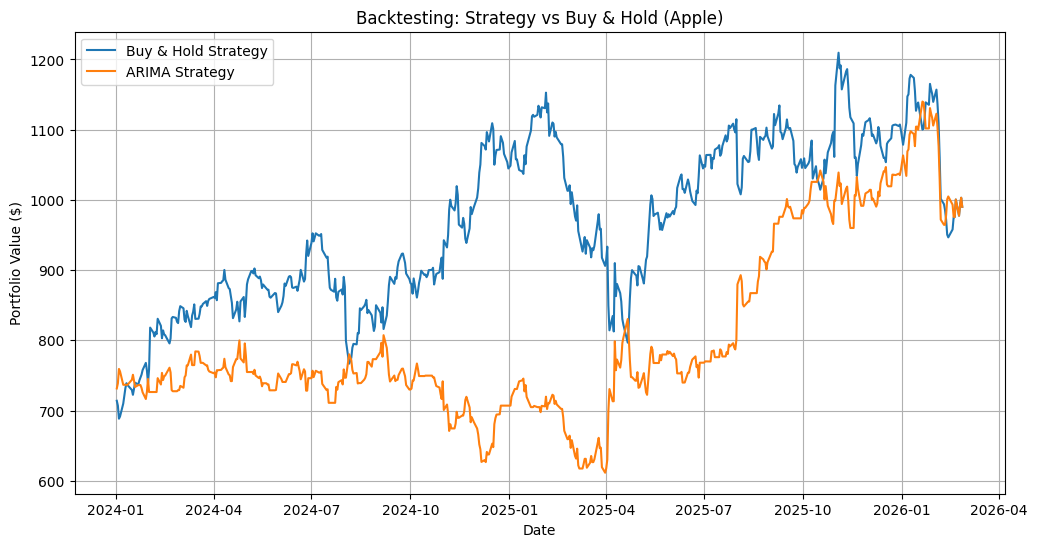

In [47]:
# Step 1: Strategy returns
strategy_returns = []

for i in range(len(test)):
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    elif signal == "SELL":
        strategy_returns.append(-actual)
    else:
        strategy_returns.append(0)

test['Strategy_Return'] = strategy_returns


# Step 2: Cumulative returns
initial_investment = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial_investment
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial_investment


# Step 3: Plot
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label='Buy & Hold Strategy')
plt.plot(test.index, test['Strategy_Cumulative'], label='ARIMA Strategy')

plt.title("Backtesting: Strategy vs Buy & Hold (Apple)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Compute Profit / Loss

In [14]:
initial_investment = 1000

# Cumulative returns
test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial_investment
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial_investment

# Final values
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

# Results table
results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        initial_investment,
        round(final_market, 2),
        round(final_strategy, 2),
        round(final_market - initial_investment, 2),
        round(final_strategy - initial_investment, 2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value   713.95
2  Strategy Final Value   731.54
3         Market Profit  -286.05
4       Strategy Profit  -268.46


Final Profit Comparison

In [15]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

print("Market Final Value:", round(final_market, 2))
print("Strategy Final Value:", round(final_strategy, 2))

print("Market Profit:", round(final_market - initial_investment, 2))
print("Strategy Profit:", round(final_strategy - initial_investment, 2))

Market Final Value: 713.95
Strategy Final Value: 731.54
Market Profit: -286.05
Strategy Profit: -268.46


AMAZON STOCK PREDICTION

Load Dataset

In [16]:
import pandas as pd

df = pd.read_csv("../../data/Amazon.csv")

df.columns = df.columns.str.strip()   # clean column names

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.columns)  # check columns

# Use correct column
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split 

In [17]:
train = df[df.index < "2024-01-01"]['Return']
test = df[df.index >= "2024-01-01"]['Return']

Tuning

In [18]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2264
Model:                 ARIMA(2, 1, 2)   Log Likelihood                5548.993
Date:                Fri, 10 Apr 2026   AIC                         -11087.986
Time:                        22:07:36   BIC                         -11059.364
Sample:                             0   HQIC                        -11077.542
                               - 2264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0131      0.015    -67.919      0.000      -1.042      -0.984
ar.L2         -0.0205      0.015     -1.391      0.164      -0.049       0.008
ma.L1         -0.0014      1.700     -0.001      0.9

In [19]:
orders = [(1,1,1), (2,1,2), (3,1,1)]

for order in orders:
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=len(test))
    
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"Order {order} → RMSE: {rmse}")

Order (1, 1, 1) → RMSE: 0.019775731751051972
Order (2, 1, 2) → RMSE: 0.019750331055588634
Order (3, 1, 1) → RMSE: 0.019777685458309945


Train Final ARIMA Model

Model Training

Using the optimal parameters, the ARIMA model is trained on the training dataset to learn patterns in stock returns.

In [20]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

Model Predictions

The trained ARIMA model is used to forecast future returns over the test period.

In [21]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(2,1,2))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test.iloc[t])

Evaluate Model

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.014157152144884878
RMSE: 0.01974008493114056


Actual vs Predicted Comparison

This visualization compares the predicted returns with actual returns.

It helps evaluate whether the model captures trends, fluctuations, and market dynamics effectively.

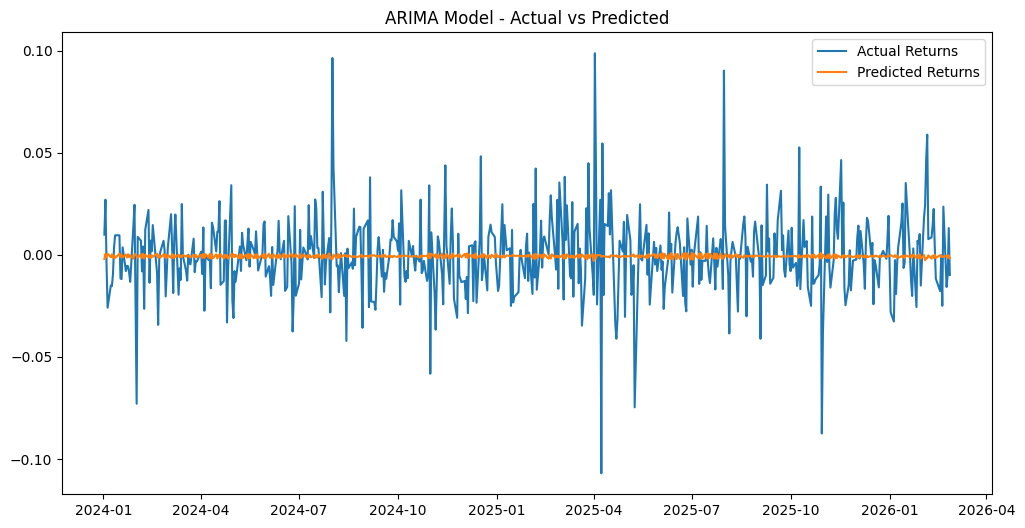

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual Returns")
plt.plot(test.index, predictions, label="Predicted Returns")

plt.title("ARIMA Model - Actual vs Predicted")
plt.legend()
plt.show()

Converting predictions to buy or sell decisions

Get Predicted Returns

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/Amazon.csv")

df.columns = df.columns.str.strip()

print(df.columns)  # now you should see 'Close' correctly

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Use Close or Adj Close (both now work)
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split

In [25]:
train = df[df.index < "2024-01-01"]
test = df[df.index >= "2024-01-01"]

ARIMA Predictions

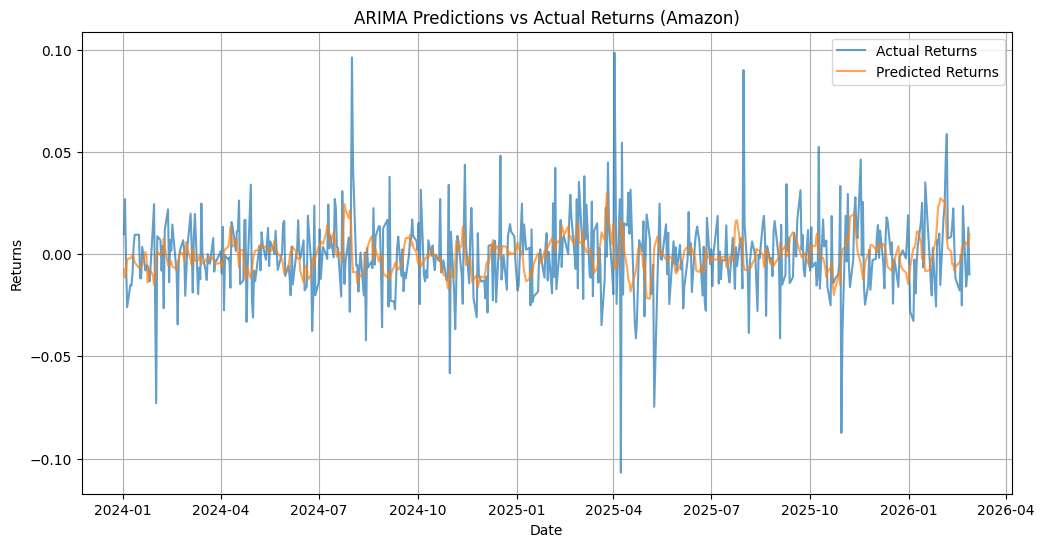

In [26]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train['Return'])
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))  # you can adjust order
    model_fit = model.fit()
    
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    history.append(test['Return'].iloc[t])

test['Predicted_Return'] = predictions


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Return'], label='Actual Returns', alpha=0.7)
plt.plot(test.index, test['Predicted_Return'], label='Predicted Returns', alpha=0.7)

plt.title("ARIMA Predictions vs Actual Returns (Amazon)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid()

plt.show()

Convert Predictions → Trading Signals

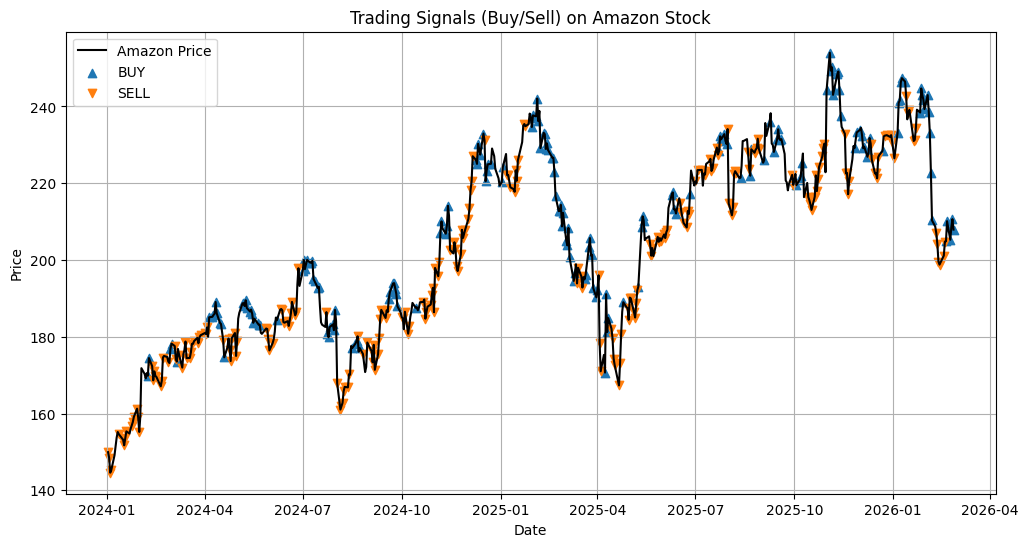

In [27]:
def get_signal(x):
    if x > 0.002:
        return "BUY"
    elif x < -0.002:
        return "SELL"
    else:
        return "HOLD"

test['Signal'] = test['Predicted_Return'].apply(get_signal)


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Close'], label='Amazon Price', color='black')

buy_signals = test[test['Signal'] == 'BUY']
sell_signals = test[test['Signal'] == 'SELL']

plt.scatter(buy_signals.index, buy_signals['Close'], label='BUY', marker='^')
plt.scatter(sell_signals.index, sell_signals['Close'], label='SELL', marker='v')

plt.title("Trading Signals (Buy/Sell) on Amazon Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

Strategy Returns

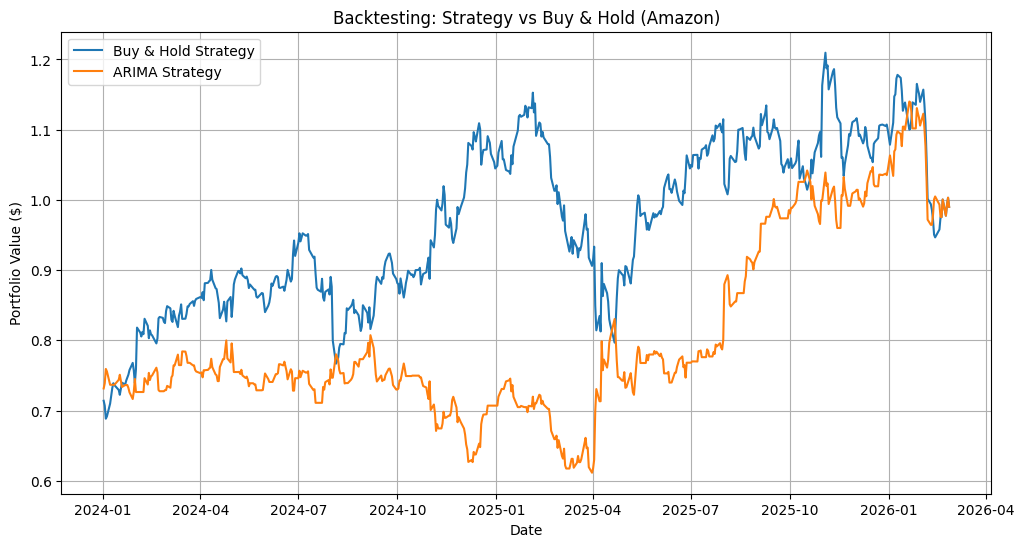

In [28]:
strategy_returns = []

for i in range(len(test)):
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    elif signal == "SELL":
        strategy_returns.append(-actual)
    else:
        strategy_returns.append(0)

test['Strategy_Return'] = strategy_returns

# ✅ ADD THESE LINES
test['Market_Cumulative'] = (1 + test['Return']).cumprod()
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod()

# Plot
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label='Buy & Hold Strategy')
plt.plot(test.index, test['Strategy_Cumulative'], label='ARIMA Strategy')

plt.title("Backtesting: Strategy vs Buy & Hold (Amazon)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()

Compute Profit / Loss

In [29]:
initial_investment = 1000

# Cumulative returns
test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial_investment
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial_investment

# Final values
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

# Results table
results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        initial_investment,
        round(final_market, 2),
        round(final_strategy, 2),
        round(final_market - initial_investment, 2),
        round(final_strategy - initial_investment, 2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value   713.95
2  Strategy Final Value   731.54
3         Market Profit  -286.05
4       Strategy Profit  -268.46


Final Profit Comparison

In [30]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

print("Market Final Value:", round(final_market, 2))
print("Strategy Final Value:", round(final_strategy, 2))

print("Market Profit:", round(final_market - initial_investment, 2))
print("Strategy Profit:", round(final_strategy - initial_investment, 2))

Market Final Value: 713.95
Strategy Final Value: 731.54
Market Profit: -286.05
Strategy Profit: -268.46


GOOGLE STOCK PREDICTION


Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

Data Loading and Preparation

In this step, we load the historical stock data and prepare it for time-series modeling by converting the Date column and setting it as the index.

In [32]:
import pandas as pd

df = pd.read_csv("../../data/google.csv")

df.columns = df.columns.str.strip()   # clean column names

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.columns)  # check columns

# Use correct column
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split

The dataset is split based on time to prevent data leakage.

Training Data: 2015–2023
Testing Data: 2024 onwards
This ensures that the model is evaluated on future unseen data.

In [33]:
train = df[df.index < "2024-01-01"]['Return']
test = df[df.index >= "2024-01-01"]['Return']

ARIMA Parameter Tuning

We perform a grid search over different ARIMA parameters (p, d, q) and select the best combination based on the lowest AIC value.

This step ensures that the model is optimized rather than using arbitrary parameters.

In [34]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

print(model_fit.summary())

orders = [(1,1,1), (2,1,2), (3,1,1)]

for order in orders:
    model = ARIMA(train, order=order)
    model_fit = model.fit()
    
    pred = model_fit.forecast(steps=len(test))
    
    from sklearn.metrics import mean_squared_error
    import numpy as np
    
    rmse = np.sqrt(mean_squared_error(test, pred))
    print(f"Order {order} → RMSE: {rmse}")

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 2264
Model:                 ARIMA(2, 1, 2)   Log Likelihood                5889.628
Date:                Fri, 10 Apr 2026   AIC                         -11769.256
Time:                        22:34:44   BIC                         -11740.634
Sample:                             0   HQIC                        -11758.812
                               - 2264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9934      0.047    -21.084      0.000      -1.086      -0.901
ar.L2         -0.0612      0.015     -4.154      0.000      -0.090      -0.032
ma.L1         -0.0548      0.045     -1.220      0.2

Train Final ARIMA Model

Model Training

Using the optimal parameters, the ARIMA model is trained on the training dataset to learn patterns in stock returns.

In [35]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

Model Predictions

The trained ARIMA model is used to forecast future returns over the test period.

In [36]:
history = list(train)
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(2,1,2))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test.iloc[t])

Model Evaluation

The model is evaluated using the following metrics:

Mean Absolute Error (MAE)
Root Mean Squared Error (RMSE)
Directional Accuracy
These metrics help assess prediction accuracy and the model's ability to capture market direction.

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.013593267359830503
RMSE: 0.018694768859634225


Actual vs Predicted Comparison

This visualization compares the predicted returns with actual returns.

It helps evaluate whether the model captures trends, fluctuations, and market dynamics effectively.

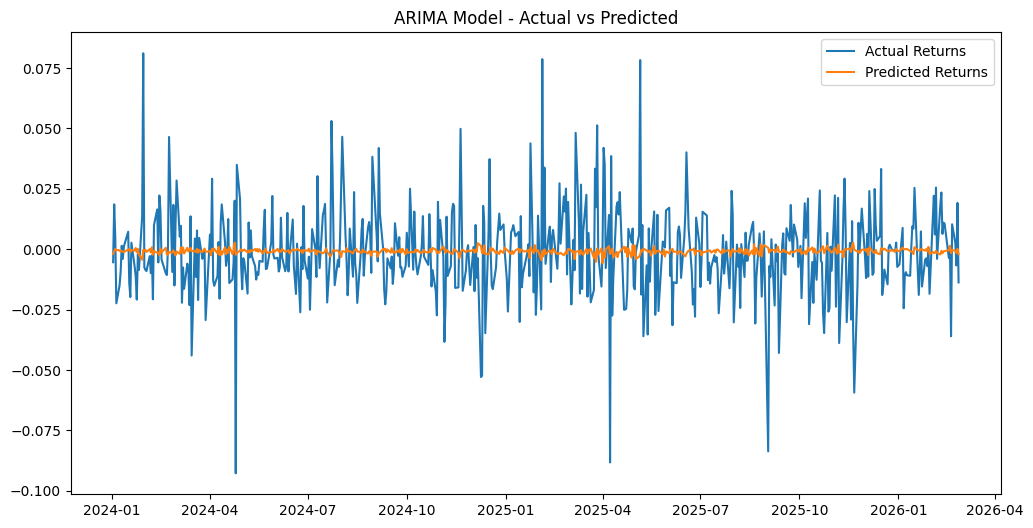

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label="Actual Returns")
plt.plot(test.index, predictions, label="Predicted Returns")

plt.title("ARIMA Model - Actual vs Predicted")
plt.legend()
plt.show()

Converting predictions to buy or sell decisions

Get Predicted Returns

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/Amazon.csv")

df.columns = df.columns.str.strip()

print(df.columns)  # now you should see 'Close' correctly

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Use Close or Adj Close (both now work)
df['Return'] = df['Close'].pct_change()

df = df.dropna()

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


Train-Test Split

In [40]:
train = df[df.index < "2024-01-01"]
test = df[df.index >= "2024-01-01"]

ARIMA Predictions

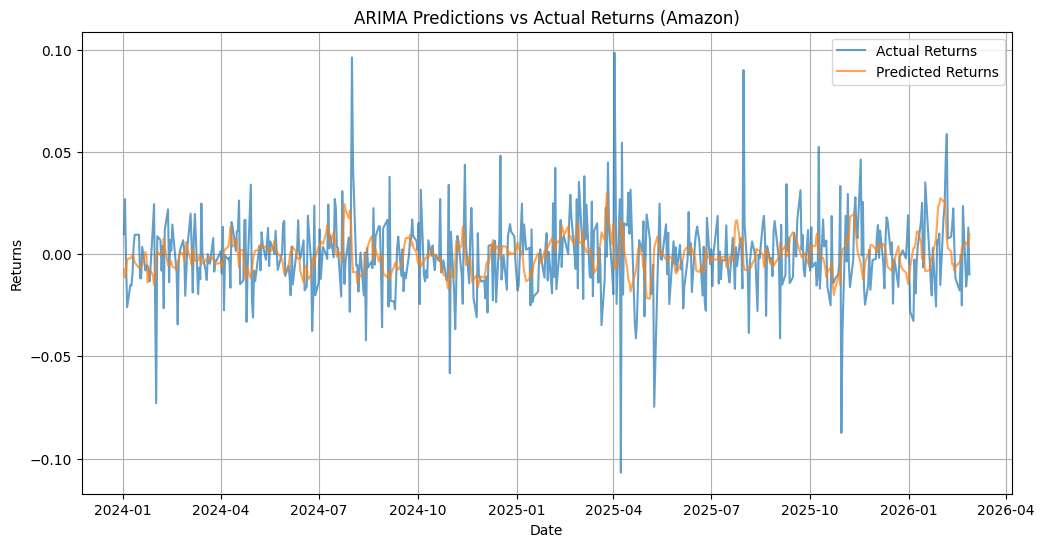

In [41]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train['Return'])
predictions = []

for t in range(len(test)):
    model = ARIMA(history, order=(5,1,0))  # you can adjust order
    model_fit = model.fit()
    
    yhat = model_fit.forecast()[0]
    predictions.append(yhat)
    
    history.append(test['Return'].iloc[t])

test['Predicted_Return'] = predictions


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Return'], label='Actual Returns', alpha=0.7)
plt.plot(test.index, test['Predicted_Return'], label='Predicted Returns', alpha=0.7)

plt.title("ARIMA Predictions vs Actual Returns (Amazon)")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid()

plt.show()

Convert Predictions → Trading Signals

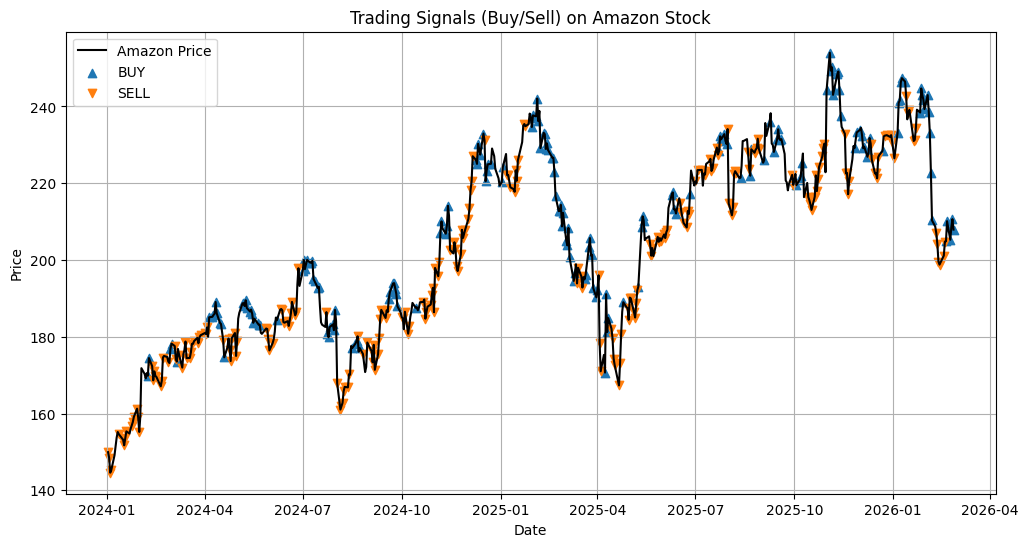

In [42]:
def get_signal(x):
    if x > 0.002:
        return "BUY"
    elif x < -0.002:
        return "SELL"
    else:
        return "HOLD"

test['Signal'] = test['Predicted_Return'].apply(get_signal)


plt.figure(figsize=(12,6))

plt.plot(test.index, test['Close'], label='Amazon Price', color='black')

buy_signals = test[test['Signal'] == 'BUY']
sell_signals = test[test['Signal'] == 'SELL']

plt.scatter(buy_signals.index, buy_signals['Close'], label='BUY', marker='^')
plt.scatter(sell_signals.index, sell_signals['Close'], label='SELL', marker='v')

plt.title("Trading Signals (Buy/Sell) on Amazon Stock")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()

plt.show()

Strategy Returns

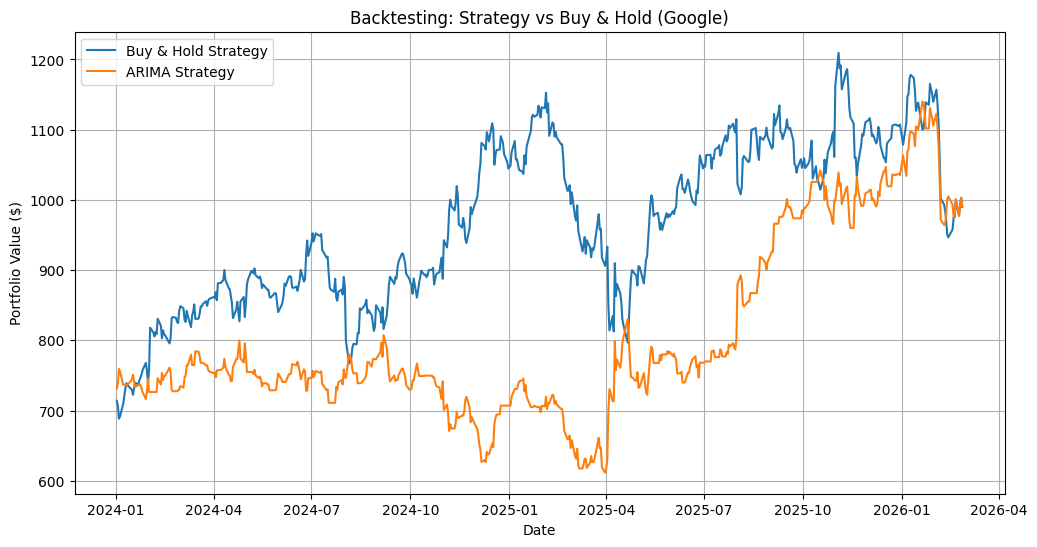

In [48]:
# Step 1: Strategy returns
strategy_returns = []

for i in range(len(test)):
    signal = test['Signal'].iloc[i]
    actual = test['Return'].iloc[i]
    
    if signal == "BUY":
        strategy_returns.append(actual)
    elif signal == "SELL":
        strategy_returns.append(-actual)
    else:
        strategy_returns.append(0)

test['Strategy_Return'] = strategy_returns


# Step 2: Cumulative returns
initial_investment = 1000

test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial_investment
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial_investment


# Step 3: Plot
plt.figure(figsize=(12,6))

plt.plot(test.index, test['Market_Cumulative'], label='Buy & Hold Strategy')
plt.plot(test.index, test['Strategy_Cumulative'], label='ARIMA Strategy')

plt.title("Backtesting: Strategy vs Buy & Hold (Google)")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid()

plt.show()


Compute Profit / Loss

In [44]:
initial_investment = 1000

# Cumulative returns
test['Market_Cumulative'] = (1 + test['Return']).cumprod() * initial_investment
test['Strategy_Cumulative'] = (1 + test['Strategy_Return']).cumprod() * initial_investment

# Final values
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

# Results table
results = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Market Final Value",
        "Strategy Final Value",
        "Market Profit",
        "Strategy Profit"
    ],
    "Value": [
        initial_investment,
        round(final_market, 2),
        round(final_strategy, 2),
        round(final_market - initial_investment, 2),
        round(final_strategy - initial_investment, 2)
    ]
})

print(results)

                 Metric    Value
0    Initial Investment  1000.00
1    Market Final Value   713.95
2  Strategy Final Value   731.54
3         Market Profit  -286.05
4       Strategy Profit  -268.46


Final Profit Comparison

In [45]:
final_market = test['Market_Cumulative'].iloc[-1]
final_strategy = test['Strategy_Cumulative'].iloc[-1]

print("Market Final Value:", round(final_market, 2))
print("Strategy Final Value:", round(final_strategy, 2))

print("Market Profit:", round(final_market - initial_investment, 2))
print("Strategy Profit:", round(final_strategy - initial_investment, 2))


Market Final Value: 713.95
Strategy Final Value: 731.54
Market Profit: -286.05
Strategy Profit: -268.46


MSFT STOCK PREDICTION

LOAD DATASET

In [ ]:
import pandas as pd

df = pd.read_csv("../../data/Amazon.csv")

df.columns = df.columns.str.strip()   # clean column names

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.columns)  # check columns

# Use correct column
df['Return'] = df['Close'].pct_change()

df = df.dropna()